---
# Hunting for Star Formation in the Local Universe
#### By: S. Sabhlok, B. Hsu, E. Prather
---
## Instructions on the Notebook
During the pre-lecture video we will go through this Python notebook through section 4.2. This way, we will be able to start at section 4.3 during class and get into some of the more fun stuff :)

---
## Background on Notebooks
Some vital information:
1. This is called a "Jupyter Notebook" (said like Jupiter Notebook). It is a common tool used by astronomers to write and develop code for their research, primarily for data analysis. It runs Python code in small blocks, each like a mini program.  
2. Each block of code is called a "cell", to run a cell you can click into it with your mouse and press `Shift-Enter`.
3. When you run a cell, some will output plots/figures or text at the bottom of them. Unless you ask the cell to print something (e.g., a string or a number) or make a plot, it won't have any output, and that's okay!
4. You may not understand fully what the code is doing and that is *totally okay*! This is as much about the astronomy as it is the code. Our goal for this notebook is to provide a soft introduction to Python code for those who have never seen it.

---

## Setup for the Notebook

Before doing anything else, we need to execute the following cell by pressing `Shift-Enter`. This cell will install some existing code we need for the Notebook and download some data that we have prepped for it.

In [36]:
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as const
import numpy as np
from specutils import Spectrum1D

## 1. Pre-Class Activity

### 1.1 Writing functions in Python
At a fundamental level, Python functions and mathematical equations are very similar. They take in a number of arguments, do some operations on them, and produce a value. Unfortunately, Python can't read mathematical notation directly, so even though the parts and the process are the same, the presentation is a bit different. The basic arithmetic operations in Python are executed via `+` (addition), `-` (subtraction), `*` (multiplication), and `/` (division).

One of the major differences between Python and handwritten equations is that to actually do calculations in Python you need to use existing libraries of mathematical functions to do some basic calculations. `NumPy` is one of the most commonly used Python libraries for doing these calculations. Some useful `NumPy` functions are:
1. `np.sqrt(x)`: The square root of the number in the parantheses. In algebraic notation you would see this as $f(x) = \sqrt{x}$.
2. `np.power(x,y)`: Raises the first number to the power of the second number inside the parantheses. In algebraic notation, you would see this as $f(x,y) = x^y$. (Interestingly, the results of the `np.sqrt` function can also come from `np.power(x, 1/2)`. Why is this? Why have two functions?) Note that this is also equivalent to `x**y` directly.
3. `np.log10(x)`: Takes the base 10 logarithm of the number in the parantheses. In algebraic notation, you would see this as $log_{10}\left(x\right)$. Note that `np.log10` and `np.log` are two separate functions, with the latter being the natural log ($log_e$).

Note that `NumPy` functions are usually called using the abbreviation `np`. So before using any NumPy function you preface it with a `np.` If you want to learn more about `NumPy` you should go checkout their very extensive documentation: https://numpy.org/.

As an example of defining a mathematical function in Python, let's use a basic physics equation that you should all be familiar with, the kinematic distance equation:
$$
\Delta y(t, v_0, a) = v_0 t + \frac{1}{2} a t^2
$$

However, say we are discussing a ball in freefall, then we know that $a = g = -9.8 m/s^2$! So we can plug this value into the above equation and remove one of our unknowns:
$$
\Delta y(t, v_0) = v_0 t - \frac{1}{2} (9.8~\rm{m}/\rm{s}^2) t^2
$$

In python, we would define this function in the following way. The variables within the parantheses after the `def` are the _inputs to the function_. Then, everything after the "return" statement is the portion of the function that returns us the result. Replace the underlines in the code cell below using the appropriate variables or numbers.

In [ ]:
#@test(test_delta_y_function)
def delta_y(t, v0):
    return ## fill in your function here

### 1.2 Plotting in Python

`Matplotlib` is the most commonly used Python library for creating data visualizations. Some useful `Matplotlib` functions are:
1. `plt.plot(x,y)`: Creates a line plot with an array of values in `x` against another array of values in `y`.
2. `plt.scatter(x,y)`: Similar to `plt.plot`, but instead creates a scatter plot with an array of values in `x` against another array of values in `y`. You can think of this as a line plot but without connecting the points.
3. `plt.hist(x)`: Creates a histogram of values in the array `x`. 

Note that `Matplotlib` plotting functions live in the `pyplot` module, usually called using the abbreviation `plt`. So before using any `Matplotlib` function you preface it with a `plt.` If you want to learn more about `Matplotlib` you should go checkout their very extensive documentation: https://matplotlib.org.

**Task:** Using the function you've defined for the kinematic distance above, plot the change in height $\Delta y$ as a function of time $t$ for an object in freefall that is initially at rest (i.e., $v_0=0$).

**Hints:**
1. To get an array of different timesteps, you can use the `NumPy` function `np.linspace(start,end,num)`. Replace `start` with your initial time, `end` with your end time, and `num` with the number of timesteps you want. For example, `np.linspace(0,10,100)` gives you 100 timesteps between 0s and 10s.

In [ ]:
#@test(test_delta_y_function)

t_vals = ## change me
y_vals = ## change me

fig = plt.figure(figsize=())

## Select a function suitable for plotting the change in height

plt.show()

---
<table align="left">
  <tr>
    <td><img src="./stop-sign.png" width=50% height=50%></img> </td>
    <td><h1>STOP HERE</h1><h3>We will finish this notebook in class!</h3></td>
  </tr>
</table>

<div style="clear: both;"></div>

<br>

---

## 2. Searching for Star Formation
### 2.1 Astronomical Spectra

Astronomers often utilize **spectra** to study astronomical objects, which emit light across a wide range of wavelengths. To put it simply, a spectrum is essential energy as a function of wavelength, and they help us understand the dominant emission process by examining the overall energy contribution across different wavelengths. To obtain a spectrum, astonomers point telescopes at an object to collect its light, which passes through a specialized instrument called a spectrograph to split up light of different wavelengths (like a prism). 

You've already seen what a spectrum of a star looks like, and that a galaxy is basically a collection of many, many stars. Let's see what a spectrum of a galaxy look like.

MODELS

http://www.iasf-milano.inaf.it/~polletta/templates/swire_templates.html

https://www.stsci.edu/science/sed/sed.html#:~:text=UV%2DOptical%20Spectra%20of%20Nearby,Back%20to%20the%20STScI%20homepage

In [107]:
np.any(spiral.flux.value<0)

True

In [113]:
spiral.flux

<Quantity [2.5233859e-21, 2.5233857e-21, 2.5233859e-21, ..., 8.5019060e-15,
           8.8297306e-15, 9.1713483e-15]>

Text(0.5, 1.0, 'Active Star Formation')

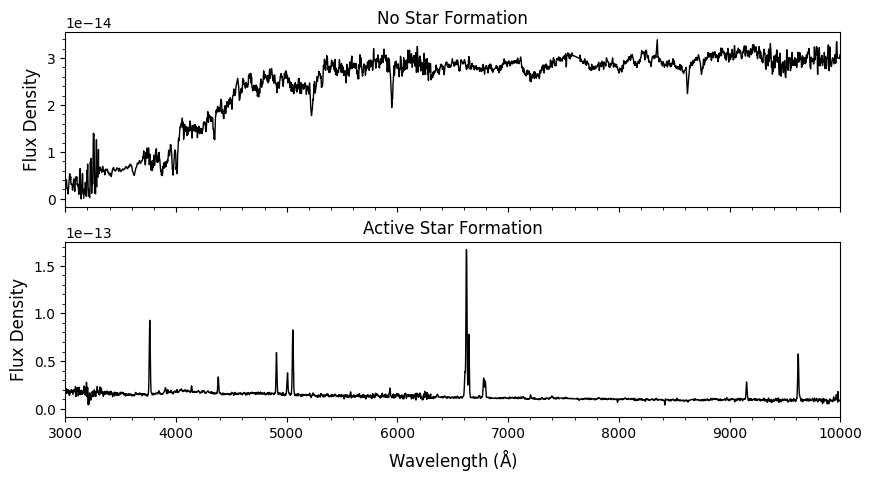

In [115]:
spiral = Spectrum1D.read('/Users/brianhsu/Downloads/sed/ngc7714.fits')
spiral.flux[spiral.flux.value<0] = np.nan
elliptical = Spectrum1D.read('/Users/brianhsu/Downloads/sed/ngc7196.fits')
elliptical.flux[elliptical.flux.value<0] = np.nan

fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True)
plt.subplots_adjust(hspace=0.2)

ax[0].plot(elliptical.spectral_axis, elliptical.flux.value, color='k', lw=1)
ax[1].plot(spiral.spectral_axis, spiral.flux.value, color='k', lw=1)

for a in ax:
#     a.set_yscale('log')
    a.set_ylabel('Flux Density', fontsize=12)
    a.minorticks_on()
    a.set_xlim(3000,10000)
ax[1].set_xlabel('Wavelength (${\\rm \\AA}$)', fontsize=12)
ax[0].set_title('No Star Formation')
ax[1].set_title('Active Star Formation')

**Task:** Comment on the key differences between a galaxy with no star formation and galaxy with active star formation.

### 2.2 From spectra to magnitudes

Now, while spectra are extremely useful, in the context of data science and population studies, they are very infeasible. This is because taking a spectrum is very time intensive. Compared to this, an image is much faster because it requires less total integration time. The pretty astronomical images that you see are pretty much "spectra" with wider wavelength bins. This is done by letting light within a certain range to pass through instead of splitting energies into fine wavelength bins, with the use of *filters*. 

Text(0.5, 1.0, 'Active Star Formation')

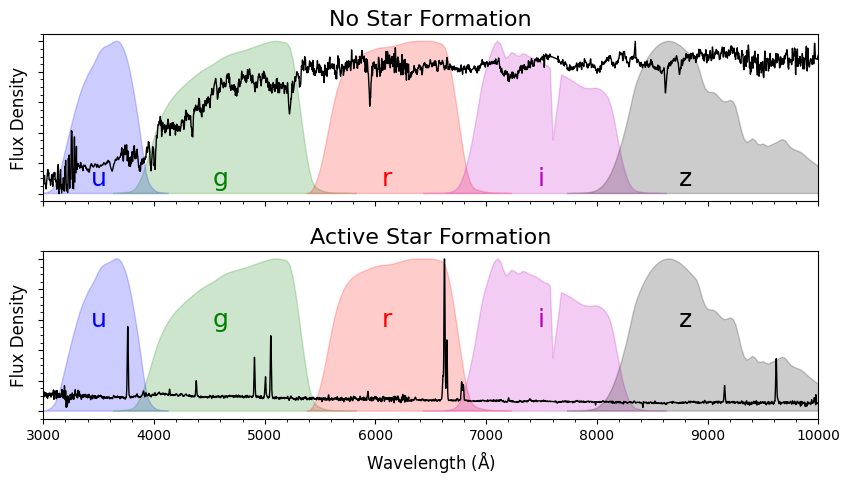

In [118]:
## hide this block

from matplotlib import pyplot as plt
from astroML.datasets import fetch_sdss_filter, fetch_vega_spectrum

fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True)
plt.subplots_adjust(hspace=0.3)

ax[0].plot(elliptical.spectral_axis, elliptical.flux.value/np.nanmax(elliptical.flux.value), color='k', lw=1)
ax[1].plot(spiral.spectral_axis, spiral.flux.value/np.nanmax(spiral.flux.value), color='k', lw=1)

text_kwargs = dict(ha='center', va='center', alpha=1, fontsize=18)
for f, c, loc in zip('ugriz', 'bgrmk', [3500, 4600, 6100, 7500, 8800]):
    data = fetch_sdss_filter(f)
    for a in ax:
        a.fill(data[0], data[1]/data[1].max(), ec=c, fc=c, alpha=0.2)
    ax[0].text(loc, 0.1, f, color=c, **text_kwargs)
    ax[1].text(loc, 0.6, f, color=c, **text_kwargs)

for a in ax:
    a.set_xlim(3000, 10000)
#     a.set_yscale('log')
    a.set_ylabel('Flux Density', fontsize=12)
    a.minorticks_on()
    a.set_yticklabels([])
ax[1].set_xlabel('Wavelength (${\\rm \\AA}$)', fontsize=12)
ax[0].set_title('No Star Formation',fontsize=16)
ax[1].set_title('Active Star Formation',fontsize=16)

**Task:** Discuss why we use $u-r$.

### 2.2.1 Computing apparent magnitude by writing a python function 

Now, consider the apparent magnitude. From each galaxy spectrum, we can convolved it with a filter to obtain a flux value within the corresponding spectral region. The value we want is the apparent magnitude $m$ as a function of flux $f$, so the apparent magnitude equation can be rewritten as 

$$
m(f, m_0) = -2.5 \log_{10}\left(f\right) + m_0
$$

Here, $m_0$ is what astronomers call a **zero-point**. You can think of this as the baseline or the reference value. This is usually calculated from an object with a well-known flux value in a given filter. For example, in the Vega system, the zero-points are defined such that Vega has an apparent magnitude of 0. There are many photometric systems, but the most commonly used system is the AB magnitude system with $m_0=-48.60$.

**Task:** Write a Python function to compute the apparent magnitude $m$ for an object with flux $f$ in a filter, in the AB magnitude system. A scaffold has been laid out below. 

**Hints:**
1. Use one of the above `NumPy` mathematical operations.
2. Python doesn't know about units, so don't worry about including parsecs or magnitudes.

In [ ]:
def flux_to_mag(variable_0, variable_1):
    # 1) Change variable_0 and variable_1 to the inputs to the apparent magnitude function 
    #    (Think about what it needs to compute the apparent magnitude!)
    # 2) Fill in the math for the apparent magnitude function after the word "return"
    #    (which numpy function do you need for log base 10?)
    # 3) Remember to use the "np." prefix when calling numpy functions!
    return 

### 2.2.2 Testing your apparent magnitude function

Now that you've written your function for the apparent magnitude, a good practice to get into is to run some tests of your function using known values. We will do that now.

In the below code cell, we've provided some code that allows you to to "call" (or use your function to return a result), by inputting appropriate values. Insert the absolute magnitude and distance values from the below table where it says CHANGEME in the code. This will place those values into the equation and use that equation to compute the apparent magnitude. Each time you get a result, compare your output with the expected answer given in the table.

| Filter | Flux ($f$) | Expected Answer ($m$) |
| -------| -----------| --------------------- |
| u      |            |                       |
| g      |            |                       |
| r      |            |                       |
| i      |            |                       |
| z      |            |                       |

In [ ]:
# test_time()

# Call your apparent_magnitude function here to see what answer you get 
# and to fill in the above table
mag = m(CHANGEME, CHANGEME)
print(f"The apparent magnitude your function calculated was m = {mag} (Compare this to the expected answer above)")

## tell them we are using u and r

$$m = -2.5\log_{10}\left(\frac{F}{F_0}\right)$$

If given a spectrum however, we can also convert it into a flux $F$. Let's assume a star has a spectrum $F_{\lambda}$ and the reference spectrum is $F_0$, the formal definition is 

$$m = -2.5\log_{10}\left(\frac{\langle F_{\lambda}\rangle}{\langle F_0\rangle}\right)$$

Given a filter with transmission function $R_{\lambda}$, the mean flux $\langle F_{\lambda}\rangle$ can be calculated via

$$\langle F_{\lambda}\rangle=\frac{\int d\lambda \lambda R_{\lambda}F_{\lambda}}{\int d\lambda \lambda R_{\lambda}}$$

From $F_{\nu}$ to $F_{\lambda}$, we won't bore you with the math, but basically you do a transformation and get 
$$F_{\nu}=\frac{\lambda^2}{c}F_{\lambda}\ \ \text{and}\ \ \frac{d\nu}{\nu}=-\frac{d\lambda}{\lambda}$$

In AB system, the zero point is $F_0=3631$ Jy. Putting everything together, 
$$m = -2.5\log_{10}\left(\frac{\int d\lambda \lambda R_{\lambda}F_{\lambda}}{\int d\lambda \lambda R_{\lambda}}\right)-48.60$$

## How does the width and location of the filter change the corresponding magnitude?

In [ ]:
def transimission(lamb, ):